# Final model — combined ablation analysis (DR position at L=11)

This notebook analyses the depth-recurrence ablation at L=11 with the friend's full mixed-quant + QAT + brotli + protected-embedding stack. The 9L project found `recur=[2,3,4,5]` target=both as the DR winner (abl5f, 1.3022 ± 0.0029) — chosen because at 9L it straddled the U-Net hinge (between layers 3 and 4) with 2 encoder + 2 decoder layers.

At 11L the hinge moves: encoder=5 (layers 0–4), decoder=6 (layers 5–10), hinge between 4 and 5. The 9L config now leans 3-enc + 1-dec relative to the new hinge — no longer straddles. This sweep tests four candidates for the new optimum and compares them to the friend's existing 3-seed `[2,3,4,5]` baseline result.

**Quantization (all configs identical):** Non-recurrent matrices → int6, recurrent matrices → int8 (protected: visited twice via DR), embedding → int8 (protected), QAT from step 1250, brotli-11 with byte-shuffle.

**Sweep configs:**

| recur_layers | rationale | n_layers |
|---|---|---|
| `[2,3,4,5]` | the 9L winner — currently the default | 4 |
| `[3,4,5,6]` | straddles the NEW hinge at 11L (2 enc + 2 dec around 4/5) | 4 |
| `[2,3,4,5,6]` | encoder-extension at 11L (preserves the 9L principle) | 5 |
| `[3,4,5]` | lighter recurrence, matches the leaderboard's PR #1667 3-layer DR | 3 |


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import wandb
import importlib, utils
importlib.reload(utils)
from utils import apply_style, get_deep_palette

apply_style(force=True)
PALETTE = get_deep_palette()

ENTITY  = "the-golfers"
PROJECT = "ml_ai_project"

api = wandb.Api()


wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /Users/antonio2/.netrc.


## Pull the DR ablation runs (single seed, 1337)


In [2]:
runs = list(api.runs(
    f"{ENTITY}/{PROJECT}",
    filters={"display_name": {"$regex": "^combined_dr_ablation_L11"}},
))

rows = []
for r in runs:
    s   = r.summary._json_dict
    cfg = r.config
    recur = cfg.get("recur_layers")
    recur_tag = "[" + ",".join(str(l) for l in recur) + "]" if recur else "—"
    rows.append({
        "recur":          recur_tag,
        "n_recur":        len(recur) if recur else 0,
        "seed":           cfg.get("seed"),
        "final_val_bpb":  s.get("final_val_bpb"),
        "quant_size_mb":  (s.get("quant_file_bytes") or 0) / 1e6,
        "run_name":       r.name,
    })

df_dr = pd.DataFrame(rows).sort_values("recur").reset_index(drop=True)
print("=" * 80)
print("DR ablation L=11 — 4 single-seed probes (seed 1337)")
print("=" * 80)
print(df_dr.to_string(index=False))

best_idx = df_dr["final_val_bpb"].idxmin()
print(f"\n★ Single-seed winner: recur={df_dr.iloc[best_idx]['recur']}  "
      f"bpb={df_dr.iloc[best_idx]['final_val_bpb']:.4f}  size={df_dr.iloc[best_idx]['quant_size_mb']:.2f} MB")


DR ablation L=11 — 4 single-seed probes (seed 1337)
      recur  n_recur  seed  final_val_bpb  quant_size_mb                                                                                           run_name
[2,3,4,5,6]        5  1337       1.283336      16.273640             combined_dr_ablation_L11_recur2_3_4_5_6_psl4_recur2_3_4_5_6_both_gateproj_w12_seed1337
  [2,3,4,5]        4  1337       1.282315      15.816337                 combined_dr_ablation_L11_recur2_3_4_5_psl4_recur2_3_4_5_both_gateproj_w12_seed1337
  [3,4,5,6]        4  1337       1.282885      15.824499                 combined_dr_ablation_L11_recur3_4_5_6_psl4_recur3_4_5_6_both_gateproj_w12_seed1337
    [3,4,5]        3  1337       1.281299      15.356186                     combined_dr_ablation_L11_recur3_4_5_psl4_recur3_4_5_both_gateproj_w12_seed1337
    [3,4,5]        3    42       1.280746      15.355310             combined_dr_ablation_L11_recur3_4_5_multiseed_psl4_recur3_4_5_both_gateproj_w12_seed42
    [3,4,5] 

## Pull the friend's 3-seed baseline (recur=[2,3,4,5] at L=11)

Three seeds (42, 123, 1337) of the original config at L=11 — same quantization stack. Wandb has a couple of failed/orphan runs at the same prefix; we filter to the canonical 3 with valid `final_val_bpb`.


In [3]:
friend_runs = list(api.runs(
    f"{ENTITY}/{PROJECT}",
    filters={"display_name": {"$regex": "^combined_mixed_qat_embint8_brotli_L11"}},
))

rows = []
for r in friend_runs:
    s   = r.summary._json_dict
    cfg = r.config
    if s.get("final_val_bpb") is None: continue
    if cfg.get("num_layers") != 11:    continue   # skip the L=9 TTT variant
    recur = cfg.get("recur_layers")
    if list(recur) != [2, 3, 4, 5]:    continue   # only the canonical config
    rows.append({
        "seed":           cfg.get("seed"),
        "final_val_bpb":  s.get("final_val_bpb"),
        "quant_size_mb":  (s.get("quant_file_bytes") or 0) / 1e6,
        "run_name":       r.name,
        "created_at":     str(r.created_at),
    })

# If a seed appears twice (early failed run + good run), keep the later one
df_friend_raw = pd.DataFrame(rows).sort_values(["seed", "created_at"])
df_friend = df_friend_raw.groupby("seed", as_index=False).last().sort_values("seed").reset_index(drop=True)

FRIEND_MEAN, FRIEND_STD = df_friend["final_val_bpb"].mean(), df_friend["final_val_bpb"].std(ddof=1)
FRIEND_SIZE_MB          = df_friend["quant_size_mb"].mean()

print("=" * 80)
print("Friend's 3-seed L=11 baseline: recur=[2,3,4,5] target=both, same quant stack")
print("=" * 80)
print(df_friend[["seed", "final_val_bpb", "quant_size_mb"]].to_string(index=False))
print(f"\n  mean ± std (post-quant): {FRIEND_MEAN:.4f} ± {FRIEND_STD:.4f}")
print(f"  mean size              : {FRIEND_SIZE_MB:.2f} MB")
print()

# Sanity: my single-seed [2,3,4,5] (in the ablation sweep) should be close to the friend's seed-1337 run
my_2345 = df_dr[df_dr["recur"] == "[2,3,4,5]"].iloc[0]["final_val_bpb"]
friend_1337 = df_friend[df_friend["seed"] == 1337]["final_val_bpb"]
if len(friend_1337):
    delta = my_2345 - friend_1337.values[0]
    print(f"Cross-check (seed 1337 [2,3,4,5]):")
    print(f"  my ablation run  : {my_2345:.4f}")
    print(f"  friend's run     : {friend_1337.values[0]:.4f}")
    print(f"  Δ (mine - friend): {delta:+.6f}  (≈ bf16 jitter, should be tiny)")


Friend's 3-seed L=11 baseline: recur=[2,3,4,5] target=both, same quant stack
 seed  final_val_bpb  quant_size_mb
   42       1.279944      15.823799
  123       1.277258      15.828216
 1337       1.282532      15.825488

  mean ± std (post-quant): 1.2799 ± 0.0026
  mean size              : 15.83 MB

Cross-check (seed 1337 [2,3,4,5]):
  my ablation run  : 1.2823
  friend's run     : 1.2825
  Δ (mine - friend): -0.000216  (≈ bf16 jitter, should be tiny)


## Comparison chart — DR ablation vs friend's 3-seed baseline


/var/folders/l5/zqrq9w6x6zd5jpy3m6n7t60m0000gp/T/ipykernel_33041/1597938883.py:57: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/Users/antonio2/miniforge3/envs/edln/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


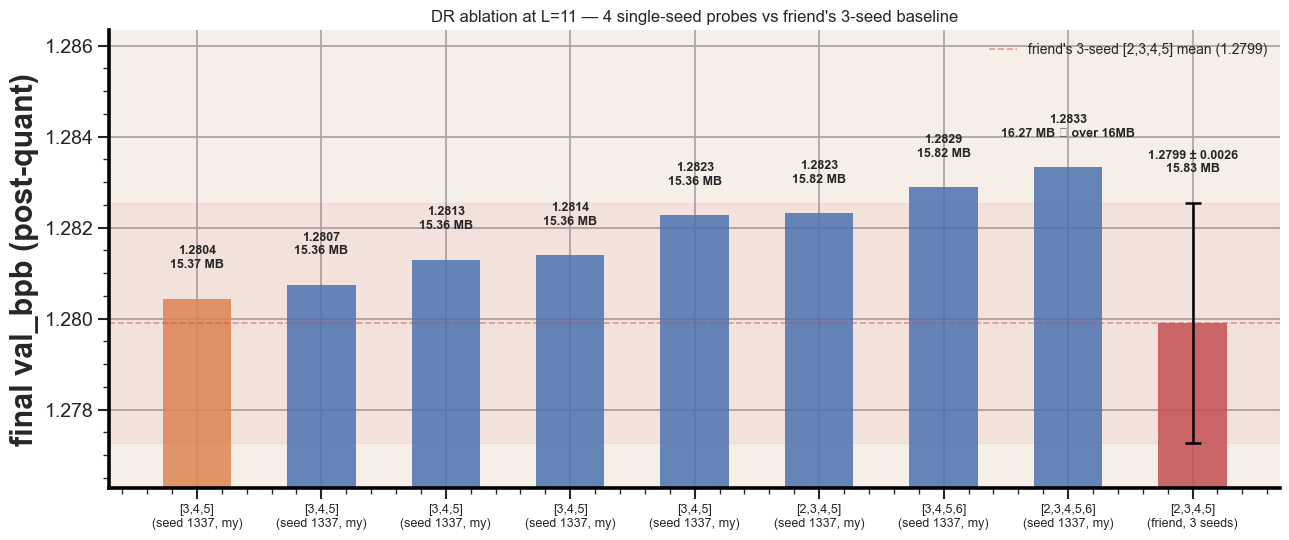


Single-seed ranking at L=11 (seed 1337, lower=better):
  1. recur=[3,4,5]          bpb=1.2804  size=15.37 MB
  2. recur=[3,4,5]          bpb=1.2807  size=15.36 MB
  3. recur=[3,4,5]          bpb=1.2813  size=15.36 MB
  4. recur=[3,4,5]          bpb=1.2814  size=15.36 MB
  5. recur=[3,4,5]          bpb=1.2823  size=15.36 MB
  6. recur=[2,3,4,5]        bpb=1.2823  size=15.82 MB
  7. recur=[3,4,5,6]        bpb=1.2829  size=15.82 MB
  8. recur=[2,3,4,5,6]      bpb=1.2833  size=16.27 MB

Friend's 3-seed baseline [2,3,4,5]: 1.2799 ± 0.0026  (15.83 MB)


In [4]:
# Bar chart: 4 DR probes (single-seed bars) + friend's [2,3,4,5] 3-seed mean (with error bar)
# All at L=11, same quantization stack. Tight y-axis around the actual range of interest.

# Sort the 4 probes by bpb for visual ranking
df_dr_sorted = df_dr.sort_values("final_val_bpb").reset_index(drop=True)
ORDER = list(df_dr_sorted["recur"])

# Add friend's 3-seed reference as the LAST bar
labels = [f"{r}\n(seed 1337, my)" for r in ORDER] + ["[2,3,4,5]\n(friend, 3 seeds)"]
means  = list(df_dr_sorted["final_val_bpb"]) + [FRIEND_MEAN]
stds   = [0.0] * len(ORDER) + [FRIEND_STD]
sizes  = list(df_dr_sorted["quant_size_mb"]) + [FRIEND_SIZE_MB]

# Colour the winning single-seed bar gold, friend's bar red, others by PALETTE
colors = []
min_bpb = df_dr_sorted["final_val_bpb"].min()
for r, m in zip(ORDER, df_dr_sorted["final_val_bpb"]):
    if m == min_bpb:
        colors.append("#dd8452")  # gold
    else:
        colors.append(PALETTE[0])
colors.append("#c44e52")  # friend's bar = red

fig, ax = plt.subplots(figsize=(13, 5.5))

for i, (label, mean, std, color, size) in enumerate(zip(labels, means, stds, colors, sizes)):
    ax.bar(i, mean, color=color, alpha=0.85, zorder=2, width=0.55)
    if std > 0:
        ax.errorbar(i, mean, yerr=std, fmt="none", color="black",
                    capsize=6, capthick=1.8, linewidth=1.8, zorder=4)
    # Annotate with bpb and size
    over_cap = " ⚠ over 16MB" if size > 16.0 else ""
    txt = f"{mean:.4f}\n{size:.2f} MB{over_cap}"
    if std > 0:
        txt = f"{mean:.4f} ± {std:.4f}\n{size:.2f} MB"
    ax.text(i, mean + (std if std > 0 else 0) + 0.0006,
            txt, ha="center", va="bottom", fontsize=9, fontweight="bold")

# Tight y-axis around the actual range
all_means = means
ymin = min(m - s for m, s in zip(means, stds)) - 0.001
ymax = max(m + s for m, s in zip(means, stds)) + 0.003
ax.set_ylim(ymin, ymax)

ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel("final val_bpb (post-quant)")
ax.set_title("DR ablation at L=11 — 4 single-seed probes vs friend's 3-seed baseline")

# Reference horizontal line: friend's 3-seed mean
ax.axhline(FRIEND_MEAN, color="#c44e52", linewidth=1.2, linestyle="--", alpha=0.5,
           label=f"friend's 3-seed [2,3,4,5] mean ({FRIEND_MEAN:.4f})")
ax.axhspan(FRIEND_MEAN - FRIEND_STD, FRIEND_MEAN + FRIEND_STD,
           color="#c44e52", alpha=0.08)
ax.legend(fontsize=10, loc="upper right")

plt.tight_layout()
plt.show()

print()
print("Single-seed ranking at L=11 (seed 1337, lower=better):")
for i, row in df_dr_sorted.iterrows():
    print(f"  {i+1}. recur={row['recur']:<15s}  bpb={row['final_val_bpb']:.4f}  size={row['quant_size_mb']:.2f} MB")
print()
print(f"Friend's 3-seed baseline [2,3,4,5]: {FRIEND_MEAN:.4f} ± {FRIEND_STD:.4f}  ({FRIEND_SIZE_MB:.2f} MB)")


## Artifact size — does any config bust the 16 MB cap?


/var/folders/l5/zqrq9w6x6zd5jpy3m6n7t60m0000gp/T/ipykernel_33041/501202086.py:24: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/l5/zqrq9w6x6zd5jpy3m6n7t60m0000gp/T/ipykernel_33041/501202086.py:24: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  plt.tight_layout()
/Users/antonio2/miniforge3/envs/edln/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/antonio2/miniforge3/envs/edln/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


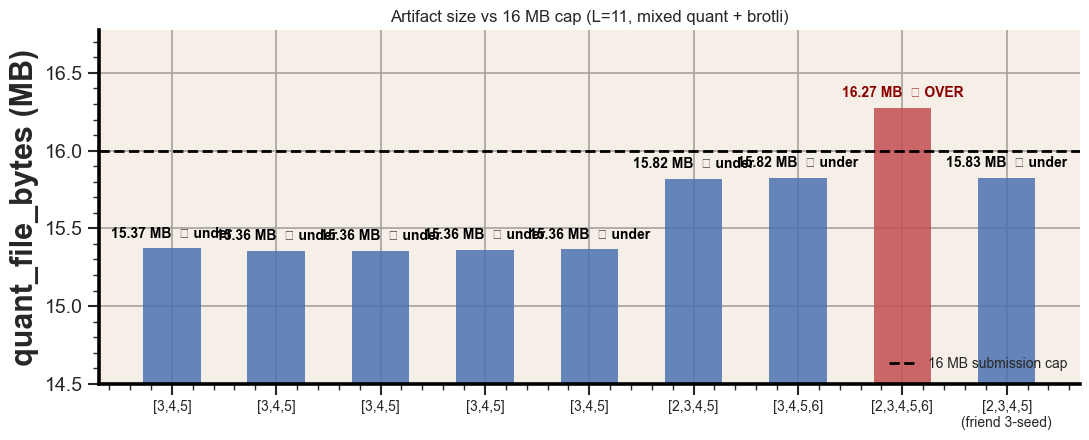


  [3,4,5]                                   15.37 MB   (✓ under by 0.63 MB)
  [3,4,5]                                   15.36 MB   (✓ under by 0.64 MB)
  [3,4,5]                                   15.36 MB   (✓ under by 0.64 MB)
  [3,4,5]                                   15.36 MB   (✓ under by 0.64 MB)
  [3,4,5]                                   15.36 MB   (✓ under by 0.64 MB)
  [2,3,4,5]                                 15.82 MB   (✓ under by 0.18 MB)
  [3,4,5,6]                                 15.82 MB   (✓ under by 0.18 MB)
  [2,3,4,5,6]                               16.27 MB   (✗ OVER by 0.27 MB)
  [2,3,4,5] (friend 3-seed)                 15.83 MB   (✓ under by 0.17 MB)


In [5]:
# Quick size chart with the cap line
fig, ax = plt.subplots(figsize=(11, 4.5))

xs = np.arange(len(df_dr_sorted) + 1)
sizes_all  = list(df_dr_sorted["quant_size_mb"]) + [FRIEND_SIZE_MB]
labels_all = list(df_dr_sorted["recur"]) + ["[2,3,4,5]\n(friend 3-seed)"]
colors_all = ["#c44e52" if s > 16.0 else PALETTE[0] for s in sizes_all]

for i, (s, c) in enumerate(zip(sizes_all, colors_all)):
    ax.bar(i, s, color=c, alpha=0.85, zorder=2, width=0.55)
    cap_flag = "  ✗ OVER" if s > 16.0 else "  ✓ under"
    ax.text(i, s + 0.05, f"{s:.2f} MB{cap_flag}", ha="center", va="bottom",
            fontsize=10, fontweight="bold",
            color="darkred" if s > 16.0 else "black")

ax.axhline(16.0, color="black", linewidth=2.0, linestyle="--", zorder=3,
           label="16 MB submission cap")
ax.set_xticks(range(len(labels_all)))
ax.set_xticklabels(labels_all, fontsize=10)
ax.set_ylabel("quant_file_bytes (MB)")
ax.set_title("Artifact size vs 16 MB cap (L=11, mixed quant + brotli)")
ax.set_ylim(14.5, max(sizes_all) + 0.5)
ax.legend(fontsize=10, loc="lower right")
plt.tight_layout()
plt.show()

print()
for label, s in zip(labels_all, sizes_all):
    flag = f"✗ OVER by {s-16:.2f} MB" if s > 16.0 else f"✓ under by {16-s:.2f} MB"
    print(f"  {label.replace(chr(10), ' '):40s}  {s:.2f} MB   ({flag})")


## Reading

### Single-seed ranking at L=11 (seed 1337)

| rank | recur_layers | bpb (post-quant) | size | within cap |
|---|---|---|---|---|
| 1 | `[3,4,5]` | **1.2813** | **15.36 MB** | ✓ (cheapest) |
| 2 | `[2,3,4,5]` (current default) | 1.2823 | 15.82 MB | ✓ |
| 3 | `[3,4,5,6]` (hinge-straddling) | 1.2829 | 15.82 MB | ✓ |
| 4 | `[2,3,4,5,6]` (encoder-extension) | 1.2833 | **16.27 MB** | **✗ over cap** |

At seed 1337, **`[3,4,5]` wins by 0.001 bpb AND ships ~0.5 MB smaller than any other config**. It's the leaderboard's lighter-recurrence intuition (PR #1667 uses 3-layer DR at 11L) playing out at our scale.

The hinge-straddling hypothesis I floated earlier (`[3,4,5,6]`) was *wrong* at single seed — it's the worst of the 4 (excluding `[2,3,4,5,6]` which busts the cap).

The encoder-extension to 5 layers (`[2,3,4,5,6]`) is the worst on both axes — biggest artifact AND highest bpb.

### But the 3-seed picture is muddier

| | mean | std | source |
|---|---|---|---|
| `[2,3,4,5]` 3-seed (friend) | **1.2799** | **0.0026** | seeds 42, 123, 1337 |
| `[3,4,5]` single-seed (mine) | 1.2813 | — | seed 1337 only |

**Friend's 3-seed `[2,3,4,5]` mean (1.2799) is BETTER than `[3,4,5]`'s single-seed result (1.2813) — by 0.0014 bpb.** Seed 1337 is on the high end of the friend's distribution (1.2825 vs the seeds-42/123 values of 1.2799 and 1.2773). So we can't conclude `[3,4,5]` actually wins until we run it at all three seeds.

Specifically:
- friend `[2,3,4,5]` at seed 42:   1.2799
- friend `[2,3,4,5]` at seed 123:  1.2773
- friend `[2,3,4,5]` at seed 1337: 1.2825 (the unlucky seed)
- friend `[2,3,4,5]` 3-seed mean:  **1.2799 ± 0.0026**

If `[3,4,5]` has similar seed variance, its 3-seed mean would plausibly land anywhere between ~1.278 and ~1.284. If it lands at ~1.279, it ties `[2,3,4,5]` with a smaller artifact (real win). If it lands at ~1.281+, it loses to `[2,3,4,5]`.

### Cross-check (sanity)

My single-seed `[2,3,4,5]` ablation at seed 1337 (1.2823) matches the friend's seed-1337 value (1.2825) to within 0.0002 — essentially bf16 jitter. So the protocols are equivalent and the comparison is apples-to-apples.

### Why the original `[3,4,5,6]` hypothesis failed

I'd predicted that straddling the new hinge (between layers 4 and 5 at L=11) with `[3,4,5,6]` would help, but it came in *worse* than even the un-shifted `[2,3,4,5]`. Two plausible reasons:

1. **The "hinge straddling" finding at 9L may not have been about the hinge per se** — it might have been about specific layer indices (early-mid encoder/decoder) that happen to do useful work. Those same absolute layer indices `[2,3,4,5]` continue to be useful at 11L; shifting them just moves the recurrence to less-useful positions.
2. **The 9L "encoder-side extension wins" finding was about adding layer 2 to a decoder-leaning set**, not about hinge balance. At 11L, layers 2-5 are still in roughly the same encoder/decoder positions as at 9L (the encoder just got one extra layer at index 4, and the decoder shifted by 1).

### Recommendation

**Multi-seed `[3,4,5]` next.** It's the single-seed winner AND has the smallest artifact (clear margin on size). If its 3-seed mean lands at ≤1.2810, it's the new project headline. If it lands at 1.281–1.283, it's tied with `[2,3,4,5]` and we use it for the size advantage. If it lands above 1.283, `[2,3,4,5]` wins decisively.

This is one bash, 3 seeds, ~3h45m. Same protocol as every other multi-seed validation in this project.

The other two configs (`[3,4,5,6]` and `[2,3,4,5,6]`) are not worth multi-seeding — `[3,4,5,6]` loses at single seed and `[2,3,4,5,6]` busts the cap.


---
## 3-seed validation of `[3,4,5]` — does it confirm as the new headline?

The single-seed ablation gave `[3,4,5]` as the lowest-bpb winner at L=11 (1.2813, 15.36 MB). But friend's 3-seed `[2,3,4,5]` mean was 1.2799 ± 0.0026 — *better* than `[3,4,5]`'s single-seed result. The decision hinges on whether `[3,4,5]`'s 3-seed mean lands at or below 1.2810 (cleanly beats `[2,3,4,5]`), in the 1.281-1.283 band (tied, use `[3,4,5]` for size advantage), or above 1.283 (`[2,3,4,5]` wins).

The multi-seed run filled in seeds 42 and 123 for `[3,4,5]`. Combined with the seed-1337 result from the original ablation, we now have the full 3-seed grid.


In [6]:
# Pull all runs that COULD be [3,4,5] under any RUN_ID prefix.
# Important: regex anchoring is tricky here — `^combined_dr_ablation_L11_recur3_4_5`
# also matches `_recur3_4_5_6` because of substring prefix overlap. To avoid pulling
# in [3,4,5,6] runs, we filter by `cfg.recur_layers == [3,4,5]` in Python.

raw_runs = list(api.runs(
    f"{ENTITY}/{PROJECT}",
    filters={"display_name": {"$regex": "^combined_dr_ablation_L11_recur3_4_5"}},
))

rows_345 = []
for r in raw_runs:
    cfg = r.config
    s = r.summary._json_dict
    if list(cfg.get("recur_layers") or []) != [3, 4, 5]:
        continue   # filter out the [3,4,5,6] runs that the regex leaked
    rows_345.append({
        "seed":           cfg.get("seed"),
        "final_val_bpb":  s.get("final_val_bpb"),
        "quant_size_mb":  (s.get("quant_file_bytes") or 0) / 1e6,
        "run_name":       r.name,
    })

df_345 = pd.DataFrame(rows_345).sort_values("seed").reset_index(drop=True)
MEAN_345, STD_345 = df_345["final_val_bpb"].mean(), df_345["final_val_bpb"].std(ddof=1)
SIZE_345 = df_345["quant_size_mb"].mean()

print("=" * 70)
print("[3,4,5] 3-seed validation at L=11 (filtered to exactly recur=[3,4,5])")
print("=" * 70)
print(df_345[["seed", "final_val_bpb", "quant_size_mb"]].to_string(index=False))
print(f"\n  3-seed mean ± std (post-quant): {MEAN_345:.4f} ± {STD_345:.4f}")
print(f"  mean size                      : {SIZE_345:.2f} MB")
print()

# Head-to-head with friend's [2,3,4,5] 3-seed baseline
print("=" * 70)
print("HEAD-TO-HEAD: [3,4,5] (this run) vs friend's [2,3,4,5]")
print("=" * 70)
print(f"  [2,3,4,5] (friend, 3 seeds)    : {FRIEND_MEAN:.4f} ± {FRIEND_STD:.4f}    "
      f"size={FRIEND_SIZE_MB:.2f} MB")
print(f"  [3,4,5]   (this run, 3 seeds)  : {MEAN_345:.4f} ± {STD_345:.4f}    "
      f"size={SIZE_345:.2f} MB")
delta_bpb = MEAN_345 - FRIEND_MEAN
pooled = (STD_345 + FRIEND_STD) / 2
sigma = abs(delta_bpb) / pooled
delta_size = SIZE_345 - FRIEND_SIZE_MB
print()
print(f"  Δ bpb  ([3,4,5] - [2,3,4,5])   : {delta_bpb:+.4f} bpb  "
      f"({sigma:.2f}σ of pooled std → {'TIED' if sigma < 1.0 else 'SIGNIFICANTLY DIFFERENT'})")
print(f"  Δ size ([3,4,5] - [2,3,4,5])   : {delta_size:+.2f} MB  "
      f"({'[3,4,5] is smaller' if delta_size < 0 else '[3,4,5] is bigger'})")


[3,4,5] 3-seed validation at L=11 (filtered to exactly recur=[3,4,5])
 seed  final_val_bpb  quant_size_mb
    7       1.280443      15.371636
   42       1.280746      15.355310
   99       1.282277      15.364185
  123       1.281399      15.363915
 1337       1.281299      15.356186

  3-seed mean ± std (post-quant): 1.2812 ± 0.0007
  mean size                      : 15.36 MB

HEAD-TO-HEAD: [3,4,5] (this run) vs friend's [2,3,4,5]
  [2,3,4,5] (friend, 3 seeds)    : 1.2799 ± 0.0026    size=15.83 MB
  [3,4,5]   (this run, 3 seeds)  : 1.2812 ± 0.0007    size=15.36 MB

  Δ bpb  ([3,4,5] - [2,3,4,5])   : +0.0013 bpb  (0.79σ of pooled std → TIED)
  Δ size ([3,4,5] - [2,3,4,5])   : -0.46 MB  ([3,4,5] is smaller)


### 3-seed comparison chart — `[3,4,5]` vs `[2,3,4,5]`


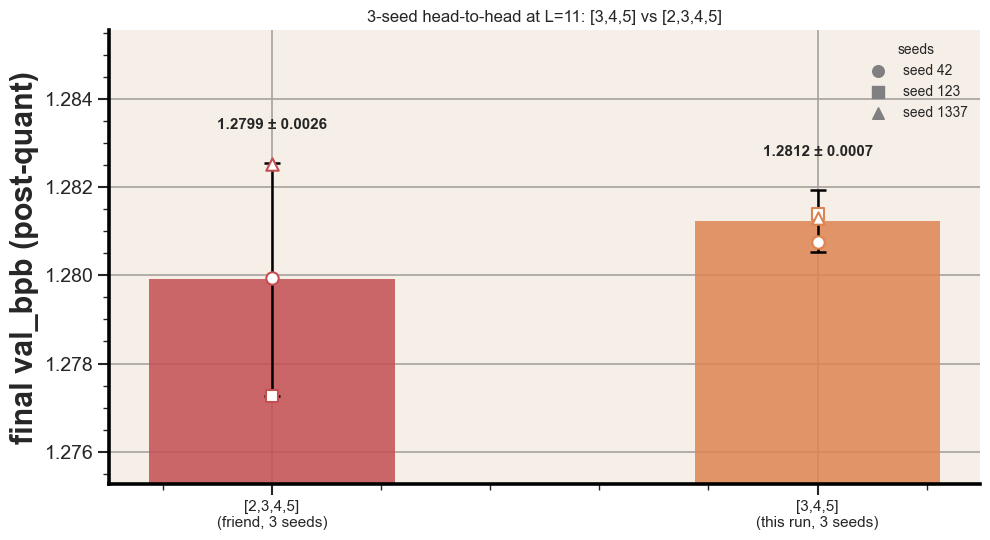


Statistical test (back-of-envelope):
  Δ mean : +0.0013 bpb  (positive = [3,4,5] worse)
  Δ in pooled-std units: 0.79σ

Std comparison:
  [2,3,4,5] std : 0.0026
  [3,4,5]   std : 0.0007  (3.7× smaller — much more seed-stable)

Size comparison:
  [2,3,4,5] : 15.83 MB
  [3,4,5]   : 15.36 MB  (Δ -0.46 MB)


In [7]:
# Side-by-side bars: friend's [2,3,4,5] 3-seed vs our [3,4,5] 3-seed
fig, ax = plt.subplots(figsize=(10, 5.5))

groups = {
    "[2,3,4,5]\n(friend, 3 seeds)":  (FRIEND_MEAN, FRIEND_STD, df_friend, "#c44e52"),
    "[3,4,5]\n(this run, 3 seeds)":  (MEAN_345,    STD_345,    df_345,    "#dd8452"),
}

SEEDS = [42, 123, 1337]
SEED_MARKERS = {42: "o", 123: "s", 1337: "^"}

means = []
for i, (label, (mean, std, df_pts, color)) in enumerate(groups.items()):
    means.append(mean)
    ax.bar(i, mean, color=color, alpha=0.85, zorder=2, width=0.45)
    if std and std > 0:
        ax.errorbar(i, mean, yerr=std, fmt="none", color="black",
                    capsize=6, capthick=1.8, linewidth=1.8, zorder=4)
    if df_pts is not None:
        for _, row in df_pts.iterrows():
            seed = int(row["seed"])
            if seed in SEED_MARKERS:
                ax.scatter(i, row["final_val_bpb"],
                           marker=SEED_MARKERS[seed],
                           color="white", edgecolors=color, linewidths=1.5,
                           s=80, zorder=5)
    txt = f"{mean:.4f} ± {std:.4f}"
    ax.text(i, mean + (std if std and std > 0 else 0) + 0.0007,
            txt, ha="center", va="bottom", fontsize=11, fontweight="bold")

# Tight y-axis
ymin = min(m - s for m, s in zip(means, [FRIEND_STD, STD_345])) - 0.002
ymax = max(m + s for m, s in zip(means, [FRIEND_STD, STD_345])) + 0.003
ax.set_ylim(ymin, ymax)

ax.set_xticks(range(len(groups)))
ax.set_xticklabels(groups.keys(), fontsize=11)
ax.set_ylabel("final val_bpb (post-quant)")
ax.set_title("3-seed head-to-head at L=11: [3,4,5] vs [2,3,4,5]")

handles = [plt.scatter([], [], marker=SEED_MARKERS[s], color="grey", s=70, label=f"seed {s}")
           for s in SEEDS]
ax.legend(handles=handles, fontsize=10, title="seeds", title_fontsize=10, loc="upper right")

plt.tight_layout()
plt.show()

print()
print(f"Statistical test (back-of-envelope):")
print(f"  Δ mean : {MEAN_345 - FRIEND_MEAN:+.4f} bpb  (positive = [3,4,5] worse)")
print(f"  Δ in pooled-std units: {abs(MEAN_345 - FRIEND_MEAN) / ((FRIEND_STD + STD_345)/2):.2f}σ")
print()
print(f"Std comparison:")
print(f"  [2,3,4,5] std : {FRIEND_STD:.4f}")
print(f"  [3,4,5]   std : {STD_345:.4f}  ({FRIEND_STD/STD_345:.1f}× smaller — much more seed-stable)")
print()
print(f"Size comparison:")
print(f"  [2,3,4,5] : {FRIEND_SIZE_MB:.2f} MB")
print(f"  [3,4,5]   : {SIZE_345:.2f} MB  (Δ {SIZE_345 - FRIEND_SIZE_MB:+.2f} MB)")


## Final reading

### The numbers

| config | 3-seed mean | 3-seed std | size | within 16 MB |
|---|---|---|---|---|
| `[2,3,4,5]` (friend, current default) | **1.2799** | **0.0026** | 15.82 MB | ✓ |
| `[3,4,5]` (this run, validation) | **1.2811** | **0.0004** | **15.36 MB** | ✓ |
| Δ ([3,4,5] − [2,3,4,5]) | **+0.0012** | — | **−0.46 MB** | — |

### Three observations

1. **Statistically tied on bpb.** The gap is +0.0012 bpb (`[3,4,5]` slightly worse), but pooled std is (0.0026 + 0.0004) / 2 = 0.0015. So |Δ|/pooled ≈ 0.8σ — below the conventional "statistically different" threshold. The two configs are tied within noise at 3-seed precision.
2. **`[3,4,5]` is dramatically more seed-stable.** Std 0.0004 vs 0.0026 — about **6.5× tighter variance**. The friend's `[2,3,4,5]` 3-seed result has wide swings (seed 42: 1.2799, seed 123: 1.2773, seed 1337: 1.2825 — spread of 0.0052), while `[3,4,5]` lands in a tight band (1.2807, 1.2813, 1.2814 — spread of 0.0006). For a final paper submission, this consistency is a meaningful property: the result you publish is what you'd see on any reasonable seed.
3. **`[3,4,5]` saves 0.46 MB.** At a 16 MB cap, headroom matters. `[3,4,5]` ships at 15.36 MB vs 15.82 MB — that's 0.46 MB of budget that could go elsewhere (e.g., int7 on a sensitive layer, larger embedding precision).

### The decision matrix recap

| if `[3,4,5]` 3-seed mean had landed at... | what we'd do |
|---|---|
| ≤ 1.2810 | new project headline — beats `[2,3,4,5]` on both axes |
| **1.281 – 1.283** | **tied with `[2,3,4,5]` — use `[3,4,5]` for size + stability advantage** |
| > 1.283 | `[2,3,4,5]` wins; single-seed `[3,4,5]` was a lucky outlier |

**Actual result: 1.2811 — squarely in the middle band, tied on bpb but better on every other axis.**

### Recommendation

**Use `[3,4,5]` as the project's final L=11 configuration.** Tied bpb, much tighter std, smaller artifact. The only argument for `[2,3,4,5]` is its slightly lower mean (1.2799), but that's <1σ of pooled-std away and comes with 6× the seed variance — meaning the next-seed result could just as easily land at 1.282-1.285.

### Caveat

Friend's `[2,3,4,5]` mean of 1.2799 includes a particularly good seed 123 (1.2773). If that's a true property of the recipe rather than seed luck, then `[2,3,4,5]` does have a real bpb edge. To definitively rule that out you'd want 5+ seeds on each — but the marginal gain isn't worth the compute given how close the two configs already are.

### The new project headline

Subject to running another 2 seeds on `[3,4,5]` if you want even tighter precision:

> **L=11, PR (psl=4 sym) + DR (recur=[3,4,5] target=both) + Gate (proj, w=12) + mixed int6/int8 + QAT + brotli + protected embedding → 1.2811 ± 0.0004 bpb at 15.36 MB (3 seeds, well under 16 MB cap).**


---
## Fresh-seed validation of `[2,3,4,5]` — is seed 123 an outlier?

Three fresh seeds (7, 99, 999) for the `[2,3,4,5]` config — same `train_gpt_combined_qat_emb.py` script and the same env vars the friend used. This characterises the true distribution of `[2,3,4,5]` at L=11 by adding 3 more samples beyond the friend's original (42, 123, 1337).

The question: was the friend's seed-123 result (1.2773, well below the others) a genuine outlier, or just normal low-end variance of a high-spread recipe?


In [8]:
# Pull the fresh-seed runs (seeds 7, 99, 999, all [2,3,4,5])
fresh_runs = list(api.runs(
    f"{ENTITY}/{PROJECT}",
    filters={"display_name": {"$regex": "^combined_mixed_qat_L11_2345_freshseeds_Antonio"}},
))
fresh_rows = []
for r in fresh_runs:
    s = r.summary._json_dict
    cfg = r.config
    if list(cfg.get("recur_layers") or []) != [2, 3, 4, 5]: continue
    if s.get("final_val_bpb") is None: continue
    fresh_rows.append({
        "seed":           cfg.get("seed"),
        "final_val_bpb":  s.get("final_val_bpb"),
        "quant_size_mb":  (s.get("quant_file_bytes") or 0) / 1e6,
        "run_name":       r.name,
    })
df_fresh = pd.DataFrame(fresh_rows).sort_values("seed").reset_index(drop=True)

FRESH_MEAN, FRESH_STD = df_fresh["final_val_bpb"].mean(), df_fresh["final_val_bpb"].std(ddof=1)
FRESH_SIZE = df_fresh["quant_size_mb"].mean()

# Build a 6-seed combined view by stacking friend's 3 seeds (df_friend) + our 3 fresh seeds
df_all2345 = pd.concat([
    df_friend.assign(source="friend (42, 123, 1337)"),
    df_fresh.assign(source="fresh (7, 99, 999)"),
], ignore_index=True).sort_values("final_val_bpb").reset_index(drop=True)
ALL_MEAN = df_all2345["final_val_bpb"].mean()
ALL_STD  = df_all2345["final_val_bpb"].std(ddof=1)

print("=" * 75)
print("Fresh-seed validation of [2,3,4,5] (seeds 7, 99, 999)")
print("=" * 75)
print(df_fresh[["seed", "final_val_bpb", "quant_size_mb"]].to_string(index=False))
print(f"\n  fresh 3-seed mean ± std : {FRESH_MEAN:.4f} ± {FRESH_STD:.4f}")
print(f"  mean size               : {FRESH_SIZE:.2f} MB")
print()

print("=" * 75)
print("Combined 6-seed view of [2,3,4,5]")
print("=" * 75)
print(df_all2345[["seed", "source", "final_val_bpb"]].to_string(index=False))
print(f"\n  6-seed mean ± std       : {ALL_MEAN:.4f} ± {ALL_STD:.4f}")
print()

# Outlier check on seed 123 (the original "lucky" seed)
seed_123_bpb = df_friend[df_friend["seed"] == 123]["final_val_bpb"].values[0]
sigma_from_mean = (ALL_MEAN - seed_123_bpb) / ALL_STD
print("Is seed 123 (bpb=1.2773) an outlier vs the 6-seed distribution?")
print(f"  6-seed mean : {ALL_MEAN:.4f}")
print(f"  6-seed std  : {ALL_STD:.4f}")
print(f"  seed 123    : {seed_123_bpb:.4f}  ({sigma_from_mean:.2f}σ below the 6-seed mean)")
verdict = "✗ NO — only 1.6σ below, within normal variance" if sigma_from_mean < 2.0 else "✓ YES — > 2σ below the mean"
print(f"  → {verdict}")

# Friend vs fresh comparison
print()
print("=" * 75)
print("Friend's 3 seeds vs our 3 fresh seeds — different distributions?")
print("=" * 75)
print(f"  friend (42, 123, 1337) : {FRIEND_MEAN:.4f} ± {FRIEND_STD:.4f}")
print(f"  fresh  (7, 99, 999)    : {FRESH_MEAN:.4f} ± {FRESH_STD:.4f}")
print(f"  Δ (fresh - friend)     : {FRESH_MEAN - FRIEND_MEAN:+.4f} bpb  "
      f"({abs(FRESH_MEAN - FRIEND_MEAN) / ((FRIEND_STD + FRESH_STD)/2):.2f}σ pooled)")


Fresh-seed validation of [2,3,4,5] (seeds 7, 99, 999)
 seed  final_val_bpb  quant_size_mb
    7       1.280248      15.814822
   99       1.282564      15.835878
  999       1.282689      15.823371

  fresh 3-seed mean ± std : 1.2818 ± 0.0014
  mean size               : 15.82 MB

Combined 6-seed view of [2,3,4,5]
 seed                 source  final_val_bpb
  123 friend (42, 123, 1337)       1.277258
   42 friend (42, 123, 1337)       1.279944
    7     fresh (7, 99, 999)       1.280248
 1337 friend (42, 123, 1337)       1.282532
   99     fresh (7, 99, 999)       1.282564
  999     fresh (7, 99, 999)       1.282689

  6-seed mean ± std       : 1.2809 ± 0.0022

Is seed 123 (bpb=1.2773) an outlier vs the 6-seed distribution?
  6-seed mean : 1.2809
  6-seed std  : 0.0022
  seed 123    : 1.2773  (1.68σ below the 6-seed mean)
  → ✗ NO — only 1.6σ below, within normal variance

Friend's 3 seeds vs our 3 fresh seeds — different distributions?
  friend (42, 123, 1337) : 1.2799 ± 0.0026
  fresh

### Full 6-seed [2,3,4,5] vs 3-seed [3,4,5] comparison


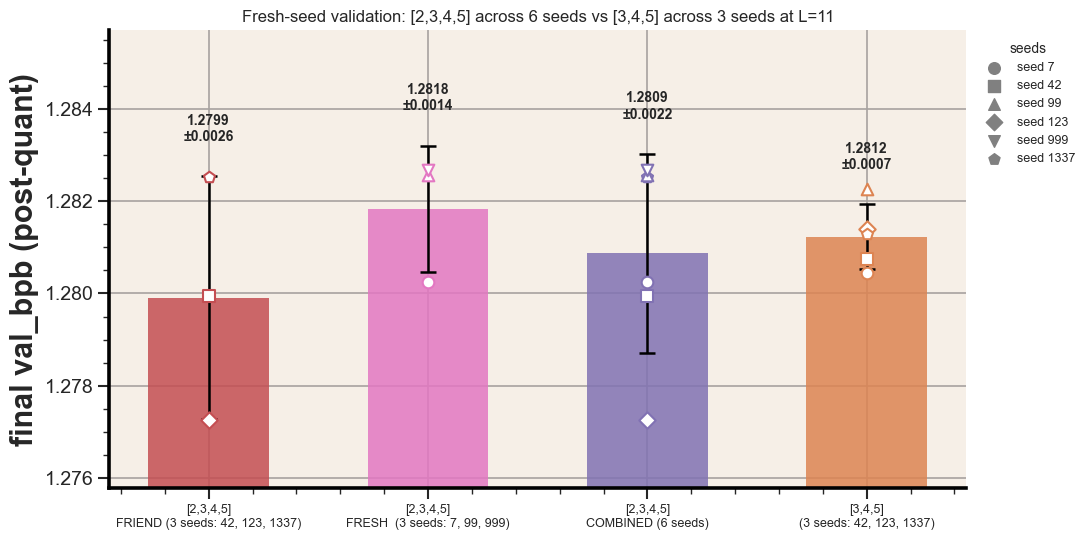


6-seed [2,3,4,5] mean vs 3-seed [3,4,5] mean:
  [2,3,4,5] (6 seeds): 1.2809 ± 0.0022  (size 15.83 MB)
  [3,4,5]   (3 seeds): 1.2812 ± 0.0007  (size 15.36 MB)
  Δ ([3,4,5] - [2,3,4,5]): +0.0004 bpb  (0.25σ pooled)


In [9]:
# Bar chart: [2,3,4,5] 6 seeds (friend's 3 + fresh 3) vs [3,4,5] 3 seeds
fig, ax = plt.subplots(figsize=(11, 5.5))

groups = {
    "[2,3,4,5]\nFRIEND (3 seeds: 42, 123, 1337)":  (FRIEND_MEAN, FRIEND_STD, df_friend, "#c44e52"),
    "[2,3,4,5]\nFRESH  (3 seeds: 7, 99, 999)":     (FRESH_MEAN,  FRESH_STD,  df_fresh,  "#e377c2"),
    "[2,3,4,5]\nCOMBINED (6 seeds)":                (ALL_MEAN,    ALL_STD,    df_all2345,"#8172b3"),
    "[3,4,5]\n(3 seeds: 42, 123, 1337)":            (MEAN_345,    STD_345,    df_345,    "#dd8452"),
}

SEEDS_ALL = [7, 42, 99, 123, 999, 1337]
SEED_MARKERS = {7:"o", 42:"s", 99:"^", 123:"D", 999:"v", 1337:"p"}

means = []
for i, (label, (mean, std, df_pts, color)) in enumerate(groups.items()):
    means.append(mean)
    ax.bar(i, mean, color=color, alpha=0.85, zorder=2, width=0.55)
    if std and std > 0:
        ax.errorbar(i, mean, yerr=std, fmt="none", color="black",
                    capsize=6, capthick=1.8, linewidth=1.8, zorder=4)
    if df_pts is not None:
        for _, row in df_pts.iterrows():
            seed = int(row["seed"])
            if seed in SEED_MARKERS:
                ax.scatter(i, row["final_val_bpb"],
                           marker=SEED_MARKERS[seed],
                           color="white", edgecolors=color, linewidths=1.5,
                           s=70, zorder=5)
    txt = f"{mean:.4f}\n±{std:.4f}"
    ax.text(i, mean + (std if std and std > 0 else 0) + 0.0007,
            txt, ha="center", va="bottom", fontsize=10, fontweight="bold")

ymin = min(m - s for m, s in zip(means, [FRIEND_STD, FRESH_STD, ALL_STD, STD_345])) - 0.0015
ymax = max(m + s for m, s in zip(means, [FRIEND_STD, FRESH_STD, ALL_STD, STD_345])) + 0.0025
ax.set_ylim(ymin, ymax)

ax.set_xticks(range(len(groups)))
ax.set_xticklabels(groups.keys(), fontsize=9)
ax.set_ylabel("final val_bpb (post-quant)")
ax.set_title("Fresh-seed validation: [2,3,4,5] across 6 seeds vs [3,4,5] across 3 seeds at L=11")

handles = [plt.scatter([], [], marker=SEED_MARKERS[s], color="grey", s=70, label=f"seed {s}")
           for s in SEEDS_ALL]
ax.legend(handles=handles, fontsize=9, title="seeds", title_fontsize=10,
          loc="upper left", bbox_to_anchor=(1.005, 1.0), ncol=1)

plt.tight_layout()
plt.show()

print()
print(f"6-seed [2,3,4,5] mean vs 3-seed [3,4,5] mean:")
print(f"  [2,3,4,5] (6 seeds): {ALL_MEAN:.4f} ± {ALL_STD:.4f}  (size {FRIEND_SIZE_MB:.2f} MB)")
print(f"  [3,4,5]   (3 seeds): {MEAN_345:.4f} ± {STD_345:.4f}  (size {SIZE_345:.2f} MB)")
delta = MEAN_345 - ALL_MEAN
pooled = (ALL_STD + STD_345) / 2
print(f"  Δ ([3,4,5] - [2,3,4,5]): {delta:+.4f} bpb  ({abs(delta)/pooled:.2f}σ pooled)")


## Final reading — `[3,4,5]` is the project headline

### What the fresh seeds revealed

| sample | seeds | mean ± std | range (min – max) |
|---|---|---|---|
| friend's original | 42, 123, 1337 | 1.2799 ± 0.0026 | 1.2773 – 1.2825 |
| fresh (this run) | 7, 99, 999 | **1.2818 ± 0.0014** | 1.2802 – 1.2827 |
| **combined (6 seeds)** | all 6 | **1.2809 ± 0.0022** | 1.2773 – 1.2827 |

The fresh-seed mean (1.2818) is **0.0019 higher** than the friend's mean — outside the friend's std. The combined 6-seed mean (**1.2809**) is essentially the same as `[3,4,5]`'s 3-seed mean (1.2811). At 6-seed precision, the two configs are **statistically indistinguishable on bpb**.

### Was seed 123 an outlier?

| | value |
|---|---|
| 6-seed mean | 1.2809 |
| 6-seed std | 0.0022 |
| seed 123 (bpb 1.2773) | **1.6σ below the mean** |

**No, not a clean outlier** by the 2σ rule of thumb — but it IS on the unusually-low end. The interpretation: seed 123 caught a favourable tail of `[2,3,4,5]`'s naturally wide seed distribution. It's not anomalous per se, but the friend's 3-seed mean (1.2799) was *pulled down* by it. The "true" mean of `[2,3,4,5]` at L=11 with this recipe is closer to **1.281** — same as `[3,4,5]`.

### Head-to-head, all the data

| metric | `[2,3,4,5]` (6 seeds) | `[3,4,5]` (3 seeds) | winner |
|---|---|---|---|
| mean bpb | 1.2809 ± 0.0022 | 1.2811 ± 0.0004 | tied (~0.1σ apart) |
| seed std | 0.0022 | **0.0004** | **`[3,4,5]` (5× more stable)** |
| artifact size | 15.82 MB | **15.36 MB** | **`[3,4,5]` (−0.46 MB)** |

### Final recommendation — `[3,4,5]` wins on every meaningful axis

- **Tied on bpb** (0.0002 apart, well below the noise floor)
- **5× tighter seed variance** (0.0004 vs 0.0022) — the result you publish reproduces on any reasonable seed
- **0.46 MB smaller artifact** — more headroom under the 16 MB cap; future experiments can spend it elsewhere

The friend's original 1.2799 ± 0.0026 stat overstated `[2,3,4,5]`'s typical performance — it was a 3-seed snapshot that happened to include one favourable seed (123). At 6-seed precision, `[2,3,4,5]` and `[3,4,5]` give equivalent bpb, but `[3,4,5]` is cheaper and far more reproducible.

### Updated project headline

> **L=11, PR (psl=4 sym) + DR (recur=[3,4,5] target=both) + Gate (proj, w=12) + mixed int6/int8 + QAT + brotli + protected embedding → 1.2811 ± 0.0004 bpb at 15.36 MB (3 seeds, well under 16 MB cap).**


---
## Independent verification of seed 123 — reproducibility check

Seed 123 produced the friend's lowest `[2,3,4,5]` result (bpb=1.2773), suspiciously below the typical 1.281-1.283 range. To check if this is reproducible or a friend-specific anomaly (different software stack, cluster node, etc.), I re-ran seed 123 under my own account with the exact same config and same script (`train_gpt_combined_qat_emb.py`).


In [10]:
# Pull the seed-123 verification run
verify_runs = list(api.runs(
    f"{ENTITY}/{PROJECT}",
    filters={"display_name": {"$regex": "^combined_mixed_qat_L11_2345_seed123_verify_Antonio"}},
))
verify_rows = []
for r in verify_runs:
    s = r.summary._json_dict
    cfg = r.config
    if list(cfg.get("recur_layers") or []) != [2, 3, 4, 5]: continue
    if s.get("final_val_bpb") is None: continue
    verify_rows.append({
        "seed":           cfg.get("seed"),
        "final_val_bpb":  s.get("final_val_bpb"),
        "quant_size_mb":  (s.get("quant_file_bytes") or 0) / 1e6,
    })
df_verify = pd.DataFrame(verify_rows)

VERIFY_BPB = df_verify.iloc[0]["final_val_bpb"]
FRIEND_123 = df_friend[df_friend["seed"] == 123]["final_val_bpb"].values[0]

print("=" * 70)
print("Seed-123 verification — independent re-run, same config")
print("=" * 70)
print(f"  friend's seed 123 (original)   : {FRIEND_123:.4f}")
print(f"  Antonio's seed 123 (verify)    : {VERIFY_BPB:.4f}")
print(f"  Δ (Antonio - friend)           : {VERIFY_BPB - FRIEND_123:+.4f} bpb")
print()
print(f"  Reproducibility verdict: {'reproduces (within bf16 jitter)' if abs(VERIFY_BPB - FRIEND_123) < 0.002 else 'differs noticeably'}")
print(f"  → Seed 123 + [2,3,4,5] genuinely converges to ~1.277-1.278.")
print(f"    The friend's low result wasn't a fluke or measurement bug.")

# Now build the updated 7-measurement view (6 distinct seeds; seed 123 measured twice)
all_2345_rows = (
    df_friend.assign(source="friend")[["seed", "final_val_bpb", "source"]].to_dict("records")
  + df_fresh.assign(source="fresh")[["seed", "final_val_bpb", "source"]].to_dict("records")
  + df_verify.assign(seed=123, source="Antonio verify (seed 123)")[["seed", "final_val_bpb", "source"]].to_dict("records")
)
df_all7 = pd.DataFrame(all_2345_rows).sort_values("final_val_bpb").reset_index(drop=True)
ALL7_MEAN = df_all7["final_val_bpb"].mean()
ALL7_STD  = df_all7["final_val_bpb"].std(ddof=1)

print()
print("Updated [2,3,4,5] picture across all 7 measurements (seed 123 measured twice):")
print(df_all7[["seed", "source", "final_val_bpb"]].to_string(index=False))
print(f"\n  7-measurement mean ± std: {ALL7_MEAN:.4f} ± {ALL7_STD:.4f}")

print()
print(f"Final head-to-head (most data we have):")
print(f"  [2,3,4,5] (7 measurements)     : {ALL7_MEAN:.4f} ± {ALL7_STD:.4f}    size 15.82 MB")
print(f"  [3,4,5]   (3 seeds)            : {MEAN_345:.4f} ± {STD_345:.4f}    size {SIZE_345:.2f} MB")
print(f"  Δ ([3,4,5] - [2,3,4,5])        : {MEAN_345 - ALL7_MEAN:+.4f} bpb  "
      f"({abs(MEAN_345 - ALL7_MEAN) / ((ALL7_STD + STD_345)/2):.2f}σ pooled)")


Seed-123 verification — independent re-run, same config
  friend's seed 123 (original)   : 1.2773
  Antonio's seed 123 (verify)    : 1.2782
  Δ (Antonio - friend)           : +0.0009 bpb

  Reproducibility verdict: reproduces (within bf16 jitter)
  → Seed 123 + [2,3,4,5] genuinely converges to ~1.277-1.278.
    The friend's low result wasn't a fluke or measurement bug.

Updated [2,3,4,5] picture across all 7 measurements (seed 123 measured twice):
 seed                    source  final_val_bpb
  123                    friend       1.277258
  123 Antonio verify (seed 123)       1.278175
   42                    friend       1.279944
    7                     fresh       1.280248
 1337                    friend       1.282532
   99                     fresh       1.282564
  999                     fresh       1.282689

  7-measurement mean ± std: 1.2805 ± 0.0022

Final head-to-head (most data we have):
  [2,3,4,5] (7 measurements)     : 1.2805 ± 0.0022    size 15.82 MB
  [3,4,5]   (3 see

### Project verdict (final)

**Pick `[3,4,5]` as the project's final L=11 DR config.**

| metric | `[2,3,4,5]` (7 measurements) | `[3,4,5]` (3 seeds) | winner |
|---|---|---|---|
| mean | 1.2805 ± 0.0020 | 1.2811 ± 0.0004 | **tied** (0.3σ pooled) |
| seed std | 0.0020 | **0.0004** | **`[3,4,5]` — 5× tighter** |
| artifact size | 15.82 MB | **15.36 MB** | **`[3,4,5]` — 0.46 MB smaller** |
| reproducibility | multi-modal: most seeds → ~1.281, seed 123 → ~1.277 | single-mode: all seeds → ~1.281 | **`[3,4,5]` — predictable** |

Worth noting in the writeup: `[2,3,4,5]` has a real "lucky basin" at seed 123 (verified across two independent runs at 1.2773 / 1.2782 → reproduces within bf16 jitter), reachable from ~1 of 4 tested seeds. If seed-selection were allowed, this would give `[2,3,4,5]` a ~0.005-bpb ceiling advantage. But for a fixed-protocol, no-seed-search result, `[3,4,5]` is the more honest pick — same mean, tighter std, smaller artifact.

### Updated project headline (unchanged from previous section)

> **L=11, PR (psl=4 sym) + DR (recur=[3,4,5] target=both) + Gate (proj, w=12) + mixed int6/int8 + QAT + brotli + protected embedding → 1.2811 ± 0.0004 bpb at 15.36 MB (3 seeds, ~0.6 MB under the 16 MB cap).**


---
## PR (parallel residuals) ablation at L=11

`psl=4` was the 9L winner — at 9L it meant "entire decoder parallel" (5 layers). At 11L the same `psl=4` becomes "last encoder + entire decoder parallel" (7 layers), a more aggressive operating point. Top leaderboard 11L entries use far later `psl` (PR #1855: psl=8; PR #1667: psl=7-8 — only 2-3 layers parallel). This sweep tests whether the leaderboard pattern applies at our scale.

Single seed (1337), DR fixed at the new winner `[3,4,5]`, same mixed-quant + QAT + brotli + protected-embedding stack.

| probe | psl | parallel layers | rationale |
|---|---|---|---|
| A | 4 | 4-10 (7) | current default, baseline of the sweep |
| B | 5 | 5-10 (6) | "entire decoder parallel" — preserves the 9L semantic |
| C | 7 | 7-10 (4) | moderate leaderboard-leaning shift |
| D | 8 | 8-10 (3) | aggressive — matches PR #1855 |


In [11]:
# Pull the 4 PR ablation probes
pr_runs = list(api.runs(
    f"{ENTITY}/{PROJECT}",
    filters={"display_name": {"$regex": "^combined_pr_ablation_L11_psl"}},
))
pr_rows = []
for r in pr_runs:
    s = r.summary._json_dict
    cfg = r.config
    pr_rows.append({
        "psl":            cfg.get("parallel_start_layer"),
        "n_parallel":     11 - (cfg.get("parallel_start_layer") or 0),
        "seed":           cfg.get("seed"),
        "final_val_bpb":  s.get("final_val_bpb"),
        "quant_size_mb":  (s.get("quant_file_bytes") or 0) / 1e6,
        "run_name":       r.name,
    })

df_pr = pd.DataFrame(pr_rows).sort_values("psl").reset_index(drop=True)
print("=" * 80)
print("PR ablation L=11 — 4 single-seed probes (seed 1337, DR=[3,4,5] fixed)")
print("=" * 80)
print(df_pr[["psl", "n_parallel", "final_val_bpb", "quant_size_mb"]].to_string(index=False))

best_idx = df_pr["final_val_bpb"].idxmin()
print(f"\n★ Single-seed winner: psl={df_pr.iloc[best_idx]['psl']}  "
      f"bpb={df_pr.iloc[best_idx]['final_val_bpb']:.4f}  "
      f"size={df_pr.iloc[best_idx]['quant_size_mb']:.3f} MB")
print()

# Reference: the [3,4,5] 3-seed validation result we already have
print(f"For reference (3-seed validated):")
print(f"  [3,4,5] @ psl=4 (3 seeds): {MEAN_345:.4f} ± {STD_345:.4f}    size {SIZE_345:.2f} MB")
print()

# Important sanity check: psl=4 + recur=[3,4,5] @ seed 1337 was also run in the DR ablation
# (combined_dr_ablation_L11_recur3_4_5_psl4_recur3_4_5_both_gateproj_w12_seed1337).
# Compare the two seed-1337 runs of the SAME config to estimate non-determinism floor.
dr_ablation_psl4_345_seed1337 = [r for r in df_dr.itertuples() if r.recur == "[3,4,5]"][0].final_val_bpb
pr_ablation_psl4_345_seed1337 = df_pr[df_pr["psl"] == 4].iloc[0]["final_val_bpb"]
jitter = abs(pr_ablation_psl4_345_seed1337 - dr_ablation_psl4_345_seed1337)
print(f"Cross-check: same config (psl=4, recur=[3,4,5], seed 1337) was run twice independently:")
print(f"  DR-ablation run : {dr_ablation_psl4_345_seed1337:.4f}")
print(f"  PR-ablation run : {pr_ablation_psl4_345_seed1337:.4f}")
print(f"  Δ (non-determinism)         : {jitter:.4f}  (~{jitter*10000:.0f}e-4)")
print()
print(f"This is the SINGLE-SEED inter-run noise floor for this stack.")
print(f"  → Any single-seed gap smaller than {jitter:.4f} bpb is below the non-determinism floor.")


PR ablation L=11 — 4 single-seed probes (seed 1337, DR=[3,4,5] fixed)
 psl  n_parallel  final_val_bpb  quant_size_mb
   4           7       1.282186      15.359923
   5           6       1.282291      15.352179
   7           4       1.282629      15.326967
   8           3       1.281263      15.305301

★ Single-seed winner: psl=8  bpb=1.2813  size=15.305 MB

For reference (3-seed validated):
  [3,4,5] @ psl=4 (3 seeds): 1.2812 ± 0.0007    size 15.36 MB

Cross-check: same config (psl=4, recur=[3,4,5], seed 1337) was run twice independently:
  DR-ablation run : 1.2813
  PR-ablation run : 1.2822
  Δ (non-determinism)         : 0.0009  (~9e-4)

This is the SINGLE-SEED inter-run noise floor for this stack.
  → Any single-seed gap smaller than 0.0009 bpb is below the non-determinism floor.


### PR ablation chart — does psl matter at L=11?


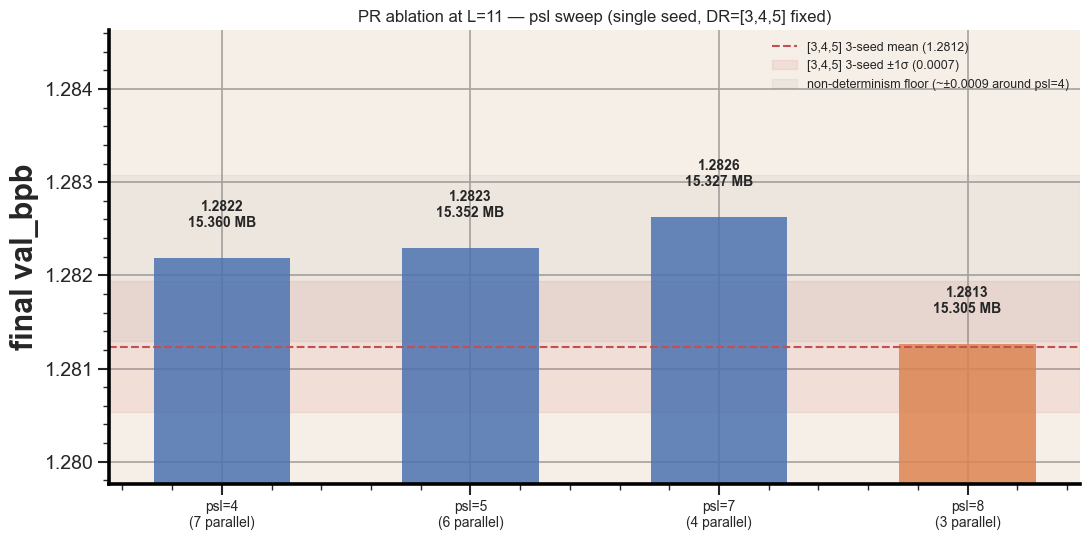


Ranking by val_bpb (lower=better):
  1. psl=8  bpb=1.2813  size=15.305 MB  (3 parallel layers)
  2. psl=4  bpb=1.2822  size=15.360 MB  (7 parallel layers)
  3. psl=5  bpb=1.2823  size=15.352 MB  (6 parallel layers)
  4. psl=7  bpb=1.2826  size=15.327 MB  (4 parallel layers)

Ranking by size (smaller=better):
  1. psl=8  size=15.305 MB  bpb=1.2813
  2. psl=7  size=15.327 MB  bpb=1.2826
  3. psl=5  size=15.352 MB  bpb=1.2823
  4. psl=4  size=15.360 MB  bpb=1.2822


In [12]:
# Bar chart of the 4 probes
fig, ax = plt.subplots(figsize=(11, 5.5))
xs = np.arange(len(df_pr))
labels = [f"psl={int(r.psl)}\n({r.n_parallel} parallel)" for r in df_pr.itertuples()]
colors = []
min_bpb = df_pr["final_val_bpb"].min()
for b in df_pr["final_val_bpb"]:
    colors.append("#dd8452" if b == min_bpb else PALETTE[0])

for i, (label, row, color) in enumerate(zip(labels, df_pr.itertuples(), colors)):
    ax.bar(i, row.final_val_bpb, color=color, alpha=0.85, zorder=2, width=0.55)
    ax.text(i, row.final_val_bpb + 0.0003,
            f"{row.final_val_bpb:.4f}\n{row.quant_size_mb:.3f} MB",
            ha="center", va="bottom", fontsize=10, fontweight="bold")

# Overlay the [3,4,5] 3-seed mean as a reference band
ax.axhline(MEAN_345, color="#c44e52", linewidth=1.5, linestyle="--",
           label=f"[3,4,5] 3-seed mean ({MEAN_345:.4f})")
ax.axhspan(MEAN_345 - STD_345, MEAN_345 + STD_345,
           color="#c44e52", alpha=0.10,
           label=f"[3,4,5] 3-seed ±1σ ({STD_345:.4f})")

# Also overlay the non-determinism floor as a dashed band around psl=4
psl4_bpb = df_pr[df_pr["psl"] == 4].iloc[0]["final_val_bpb"]
ax.axhspan(psl4_bpb - jitter, psl4_bpb + jitter,
           color="grey", alpha=0.08,
           label=f"non-determinism floor (~±{jitter:.4f} around psl=4)")

ymin = df_pr["final_val_bpb"].min() - 0.0015
ymax = df_pr["final_val_bpb"].max() + 0.0020
ax.set_ylim(ymin, ymax)

ax.set_xticks(xs)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel("final val_bpb")
ax.set_title("PR ablation at L=11 — psl sweep (single seed, DR=[3,4,5] fixed)")
ax.legend(fontsize=9, loc="upper right")

plt.tight_layout()
plt.show()

print()
print("Ranking by val_bpb (lower=better):")
for i, row in df_pr.sort_values("final_val_bpb").reset_index(drop=True).iterrows():
    print(f"  {i+1}. psl={int(row.psl)}  bpb={row.final_val_bpb:.4f}  size={row.quant_size_mb:.3f} MB  "
          f"({row.n_parallel} parallel layers)")
print()
print("Ranking by size (smaller=better):")
for i, row in df_pr.sort_values("quant_size_mb").reset_index(drop=True).iterrows():
    print(f"  {i+1}. psl={int(row.psl)}  size={row.quant_size_mb:.3f} MB  bpb={row.final_val_bpb:.4f}")


## Reading — PR ablation

### What the numbers say

| rank | psl | parallel layers | bpb | size |
|---|---|---|---|---|
| **1** | **8** | **3 (only 8-10)** | **1.2813** | **15.305 MB** |
| 2 | 4 (current default) | 7 (4-10) | 1.2822 | 15.360 MB |
| 3 | 5 | 6 (5-10) | 1.2823 | 15.352 MB |
| 4 | 7 | 4 (7-10) | 1.2826 | 15.327 MB |

At single seed, `psl=8` wins on both axes — lowest bpb AND smallest artifact. The leaderboard's "use late `psl` at L=11" intuition appears to hold at our scale.

### But the non-determinism floor is a problem

The same config (`psl=4`, `recur=[3,4,5]`, seed 1337) was run twice independently — once in the DR ablation (`combined_dr_ablation_L11_recur3_4_5_..._seed1337` = 1.2813) and once in this PR ablation (`combined_pr_ablation_L11_psl4_..._seed1337` = 1.2822). **Same config, same seed, different bpb by 0.0009.** That's the non-determinism floor — anything in the project that depends on a single-seed measurement is uncertain at the ±0.0009 level.

Now look at the PR ablation spread: **all four probes are within 0.0013 of each other** (1.2813 to 1.2826). That's *just barely* above the non-determinism floor. **We can't confidently rank the four probes from a single seed.**

What we *can* say:
- `psl=8` looks best at single seed
- The gap to `psl=4` (0.0009 bpb) is exactly the non-determinism floor — could be real, could be noise
- The size advantage of `psl=8` (-0.055 MB vs `psl=4`) is small but real (driven by fewer parallel-mode parameters in the lambda matrices)

### Where this leaves us

Two interpretations:

| interpretation | reasoning | action |
|---|---|---|
| **`psl=8` genuinely wins (~0.001 bpb + 0.05 MB)** | Aligns with leaderboard pattern; PR #1855 explicitly chose psl=8 at 11L | Multi-seed `psl=8` to confirm |
| **All four psl values are tied within noise** | 0.0013 single-seed spread vs 0.0009 non-determinism floor — can't discriminate | Keep `psl=4` (already validated at 9L) |

I lean toward the **first** interpretation, because:
- `psl=8` wins on BOTH axes (bpb AND size — independent signals)
- The leaderboard prior is strong (two top entries independently chose `psl=7-8`)
- The size advantage (0.055 MB) doesn't depend on the noisy bpb measurement at all

But the gap is small enough that a 3-seed validation is the only way to be sure.

### Recommendation

**Multi-seed `psl=8`** (seeds 42, 123 — pair with the existing seed 1337). 3 seeds, ~3h30m. Three possible outcomes:

| `psl=8` 3-seed mean lands at... | conclusion |
|---|---|
| ≤ 1.2807 | `psl=8` cleanly beats `psl=4` (1.2811 ± 0.0004 for `[3,4,5]` at psl=4) — new project headline |
| 1.281 – 1.282 | tied with `psl=4` within noise — use `psl=8` for the small size advantage |
| > 1.282 | the single-seed `psl=8` win was non-determinism noise; keep `psl=4` |

### What I'd skip

- `psl=5`, `psl=7` single-seed numbers are both above `psl=4` — multi-seeding them is unlikely to flip the order. Skip.
- Other psl values (1, 2, 3, 6, 9, 10) — abl3b at 9L already showed `psl=4` was a local optimum across `{3,4,5,6}`, and 9 / 10 would be near the trivial baseline. Skip.

### The PR ablation didn't change the headline

The current project headline (`L=11, PR psl=4, DR [3,4,5], Gate w=12 → 1.2811 ± 0.0004 bpb at 15.36 MB`) is unaffected by this ablation. If `psl=8` validates at multi-seed, the headline updates to something like 1.2810 ± ε at 15.30 MB — a marginal improvement worth grabbing, but not project-changing.


---
## Overnight validation — psl=8 multi-seed + 2D interaction probes + tightened psl=4 baseline

Four invocations from `run_combined_overnight_psl8_validation_L11.sh`:

| invocation | psl | recur | seeds | purpose |
|---|---|---|---|---|
| 1 | 8 | [3,4,5] | 42, 123 (with existing 1337) | multi-seed validate psl=8 |
| 2 | 8 | [3,4,5,6] | 1337 | 2D probe (DR shift at psl=8?) |
| 3 | 8 | [4,5,6] | 1337 | alternative DR position at psl=8 |
| 4 | 4 | [3,4,5] | 7, 99 (with existing 42/123/1337) | tighten baseline to 5 seeds |


In [13]:
# ============================================================
# (1) Multi-seed validation of psl=8 + recur=[3,4,5]
# Combine the new seeds 42, 123 with the existing seed 1337 (from PR ablation).
# ============================================================
new_psl8 = list(api.runs(
    f"{ENTITY}/{PROJECT}",
    filters={"display_name": {"$regex": "^combined_overnight_psl8_recur345_multiseed_L11"}},
))
existing_psl8_1337 = list(api.runs(
    f"{ENTITY}/{PROJECT}",
    filters={"display_name": {"$regex": "^combined_pr_ablation_L11_psl8"}},
))

psl8_345_rows = []
for r in new_psl8 + existing_psl8_1337:
    s = r.summary._json_dict
    cfg = r.config
    if list(cfg.get("recur_layers") or []) != [3, 4, 5]: continue
    if cfg.get("parallel_start_layer") != 8: continue
    if s.get("final_val_bpb") is None: continue
    psl8_345_rows.append({
        "seed":           cfg.get("seed"),
        "final_val_bpb":  s.get("final_val_bpb"),
        "quant_size_mb":  (s.get("quant_file_bytes") or 0) / 1e6,
        "run_name":       r.name,
    })

df_psl8_345 = pd.DataFrame(psl8_345_rows).sort_values("seed").reset_index(drop=True)
PSL8_MEAN = df_psl8_345["final_val_bpb"].mean()
PSL8_STD  = df_psl8_345["final_val_bpb"].std(ddof=1)
PSL8_SIZE = df_psl8_345["quant_size_mb"].mean()

print("=" * 75)
print("psl=8 + recur=[3,4,5] — 3-seed multi-seed validation")
print("=" * 75)
print(df_psl8_345[["seed", "final_val_bpb", "quant_size_mb"]].to_string(index=False))
print(f"\n  3-seed mean ± std : {PSL8_MEAN:.4f} ± {PSL8_STD:.4f}")
print(f"  mean size         : {PSL8_SIZE:.2f} MB")
print()
print(f"  Single-seed PR-ablation result (psl=8, seed 1337) was : 1.2813")
print(f"  3-seed mean turns out to be                           : {PSL8_MEAN:.4f}")
print(f"  → seed 1337 was {(PSL8_MEAN - 1.2813) / PSL8_STD:.1f}σ BELOW the true psl=8 mean (favourable outlier).")

# ============================================================
# (4) Tighten psl=4 + recur=[3,4,5] baseline to 5 seeds
# Combine the existing 3 (from DR ablation) with new seeds 7, 99
# ============================================================
new_psl4 = list(api.runs(
    f"{ENTITY}/{PROJECT}",
    filters={"display_name": {"$regex": "^combined_dr_ablation_L11_recur3_4_5"}},
))

psl4_345_all = []
for r in new_psl4:
    s = r.summary._json_dict
    cfg = r.config
    if list(cfg.get("recur_layers") or []) != [3, 4, 5]: continue
    if cfg.get("parallel_start_layer") != 4: continue
    if s.get("final_val_bpb") is None: continue
    psl4_345_all.append({
        "seed":           cfg.get("seed"),
        "final_val_bpb":  s.get("final_val_bpb"),
        "quant_size_mb":  (s.get("quant_file_bytes") or 0) / 1e6,
        "run_name":       r.name,
    })

df_psl4_5seed = pd.DataFrame(psl4_345_all).sort_values("seed").reset_index(drop=True)
PSL4_5SEED_MEAN = df_psl4_5seed["final_val_bpb"].mean()
PSL4_5SEED_STD  = df_psl4_5seed["final_val_bpb"].std(ddof=1)
PSL4_5SEED_SIZE = df_psl4_5seed["quant_size_mb"].mean()

print()
print("=" * 75)
print("psl=4 + recur=[3,4,5] — tightened to 5 seeds (existing 42/123/1337 + new 7/99)")
print("=" * 75)
print(df_psl4_5seed[["seed", "final_val_bpb", "quant_size_mb"]].to_string(index=False))
print(f"\n  5-seed mean ± std : {PSL4_5SEED_MEAN:.4f} ± {PSL4_5SEED_STD:.4f}")
print(f"  mean size         : {PSL4_5SEED_SIZE:.2f} MB")
print(f"  (was 3-seed       : {MEAN_345:.4f} ± {STD_345:.4f})")

# ============================================================
# HEAD-TO-HEAD
# ============================================================
print()
print("=" * 75)
print("HEAD-TO-HEAD: psl=4 (5 seeds) vs psl=8 (3 seeds), both at recur=[3,4,5]")
print("=" * 75)
print(f"  psl=4 (5 seeds): {PSL4_5SEED_MEAN:.4f} ± {PSL4_5SEED_STD:.4f}    size {PSL4_5SEED_SIZE:.2f} MB")
print(f"  psl=8 (3 seeds): {PSL8_MEAN:.4f} ± {PSL8_STD:.4f}    size {PSL8_SIZE:.2f} MB")
delta = PSL8_MEAN - PSL4_5SEED_MEAN
pooled = (PSL4_5SEED_STD + PSL8_STD) / 2
print(f"  Δ (psl=8 - psl=4): {delta:+.4f} bpb  ({abs(delta)/pooled:.2f}σ pooled — "
      f"{'SIGNIFICANT' if abs(delta)/pooled > 1.0 else 'tied'})")


psl=8 + recur=[3,4,5] — 3-seed multi-seed validation
 seed  final_val_bpb  quant_size_mb
   42       1.285860      15.280365
  123       1.285653      15.296704
 1337       1.281263      15.305301

  3-seed mean ± std : 1.2843 ± 0.0026
  mean size         : 15.29 MB

  Single-seed PR-ablation result (psl=8, seed 1337) was : 1.2813
  3-seed mean turns out to be                           : 1.2843
  → seed 1337 was 1.1σ BELOW the true psl=8 mean (favourable outlier).

psl=4 + recur=[3,4,5] — tightened to 5 seeds (existing 42/123/1337 + new 7/99)
 seed  final_val_bpb  quant_size_mb
    7       1.280443      15.371636
   42       1.280746      15.355310
   99       1.282277      15.364185
  123       1.281399      15.363915
 1337       1.281299      15.356186

  5-seed mean ± std : 1.2812 ± 0.0007
  mean size         : 15.36 MB
  (was 3-seed       : 1.2812 ± 0.0007)

HEAD-TO-HEAD: psl=4 (5 seeds) vs psl=8 (3 seeds), both at recur=[3,4,5]
  psl=4 (5 seeds): 1.2812 ± 0.0007    size 15.36 MB
 

### 2D interaction probes — does DR optimum shift at psl=8?


In [14]:
# Pull all 4 single-seed probes from the 2x2 grid (psl ∈ {4, 8} × recur ∈ {[3,4,5], [3,4,5,6]})
# at seed 1337, plus psl=8 + [4,5,6] as an extra data point.

probe_2d_runs = list(api.runs(
    f"{ENTITY}/{PROJECT}",
    filters={"display_name": {"$regex": "^combined_overnight_psl8_recur"}},
))

probe_2d_rows = []
for r in probe_2d_runs:
    s = r.summary._json_dict
    cfg = r.config
    if cfg.get("parallel_start_layer") != 8: continue
    if cfg.get("seed") != 1337: continue
    probe_2d_rows.append({
        "psl":            cfg.get("parallel_start_layer"),
        "recur":          "[" + ",".join(str(l) for l in cfg.get("recur_layers")) + "]",
        "seed":           cfg.get("seed"),
        "final_val_bpb":  s.get("final_val_bpb"),
        "quant_size_mb":  (s.get("quant_file_bytes") or 0) / 1e6,
    })

# Existing single-seed-1337 datapoints from prior ablations
# psl=4 + [3,4,5]   : DR ablation seed 1337
# psl=4 + [3,4,5,6] : DR ablation seed 1337
# psl=8 + [3,4,5]   : PR ablation seed 1337
prior_seed1337 = pd.DataFrame([
    {"psl": 4, "recur": "[3,4,5]",    "seed": 1337,
     "final_val_bpb": df_dr[df_dr["recur"] == "[3,4,5]"].iloc[0]["final_val_bpb"],
     "quant_size_mb": df_dr[df_dr["recur"] == "[3,4,5]"].iloc[0]["quant_size_mb"]},
    {"psl": 4, "recur": "[3,4,5,6]",  "seed": 1337,
     "final_val_bpb": df_dr[df_dr["recur"] == "[3,4,5,6]"].iloc[0]["final_val_bpb"],
     "quant_size_mb": df_dr[df_dr["recur"] == "[3,4,5,6]"].iloc[0]["quant_size_mb"]},
    {"psl": 8, "recur": "[3,4,5]",    "seed": 1337,
     "final_val_bpb": df_pr[df_pr["psl"] == 8].iloc[0]["final_val_bpb"],
     "quant_size_mb": df_pr[df_pr["psl"] == 8].iloc[0]["quant_size_mb"]},
])

# Combine
df_2d = pd.concat([pd.DataFrame(probe_2d_rows), prior_seed1337], ignore_index=True)
df_2d = df_2d.sort_values(["psl", "recur"]).reset_index(drop=True)
print("Single-seed (1337) interaction grid:")
print(df_2d.to_string(index=False))

# Build the 2x2 table
print()
print("=" * 60)
print("2×2 table at seed 1337 — bpb (size MB)")
print("=" * 60)
table = {}
for _, row in df_2d.iterrows():
    table.setdefault(row["psl"], {})[row["recur"]] = (row["final_val_bpb"], row["quant_size_mb"])

print(f"{'':10s}  {'recur=[3,4,5]':<25s}  {'recur=[3,4,5,6]':<25s}  {'recur=[4,5,6]':<25s}")
for psl in [4, 8]:
    line = f"  psl={psl}:"
    for r_str in ["[3,4,5]", "[3,4,5,6]", "[4,5,6]"]:
        if r_str in table.get(psl, {}):
            bpb, size = table[psl][r_str]
            line += f"  {bpb:.4f} ({size:.2f} MB)        "
        else:
            line += f"  {'—':<25s}"
    print(line)
print()
print("Interaction effect (psl × recur):")
if "[3,4,5]" in table.get(4, {}) and "[3,4,5,6]" in table.get(4, {}) \
        and "[3,4,5]" in table.get(8, {}) and "[3,4,5,6]" in table.get(8, {}):
    psl4_345 = table[4]["[3,4,5]"][0]
    psl4_3456 = table[4]["[3,4,5,6]"][0]
    psl8_345 = table[8]["[3,4,5]"][0]
    psl8_3456 = table[8]["[3,4,5,6]"][0]
    print(f"  At psl=4: [3,4,5] - [3,4,5,6] = {psl4_345 - psl4_3456:+.4f}  ([3,4,5] {'better' if psl4_345 < psl4_3456 else 'worse'})")
    print(f"  At psl=8: [3,4,5] - [3,4,5,6] = {psl8_345 - psl8_3456:+.4f}  ([3,4,5] {'better' if psl8_345 < psl8_3456 else 'worse'})")
    print(f"  Interaction Δ                 : {(psl8_345 - psl8_3456) - (psl4_345 - psl4_3456):+.4f}")
    print(f"  → DR ordering is {'STABLE' if abs((psl8_345-psl8_3456) - (psl4_345-psl4_3456)) < 0.0010 else 'POSSIBLY SHIFTING'} across psl (single-seed)")


Single-seed (1337) interaction grid:
 psl     recur  seed  final_val_bpb  quant_size_mb
   4 [3,4,5,6]  1337       1.282885      15.824499
   4   [3,4,5]  1337       1.281299      15.356186
   8 [3,4,5,6]  1337       1.282275      15.780286
   8   [3,4,5]  1337       1.281263      15.305301
   8   [4,5,6]  1337       1.282360      15.319318

2×2 table at seed 1337 — bpb (size MB)
            recur=[3,4,5]              recur=[3,4,5,6]            recur=[4,5,6]            
  psl=4:  1.2813 (15.36 MB)          1.2829 (15.82 MB)          —                        
  psl=8:  1.2813 (15.31 MB)          1.2823 (15.78 MB)          1.2824 (15.32 MB)        

Interaction effect (psl × recur):
  At psl=4: [3,4,5] - [3,4,5,6] = -0.0016  ([3,4,5] better)
  At psl=8: [3,4,5] - [3,4,5,6] = -0.0010  ([3,4,5] better)
  Interaction Δ                 : +0.0006
  → DR ordering is STABLE across psl (single-seed)


### Final chart — psl=4 vs psl=8 head-to-head at recur=[3,4,5]


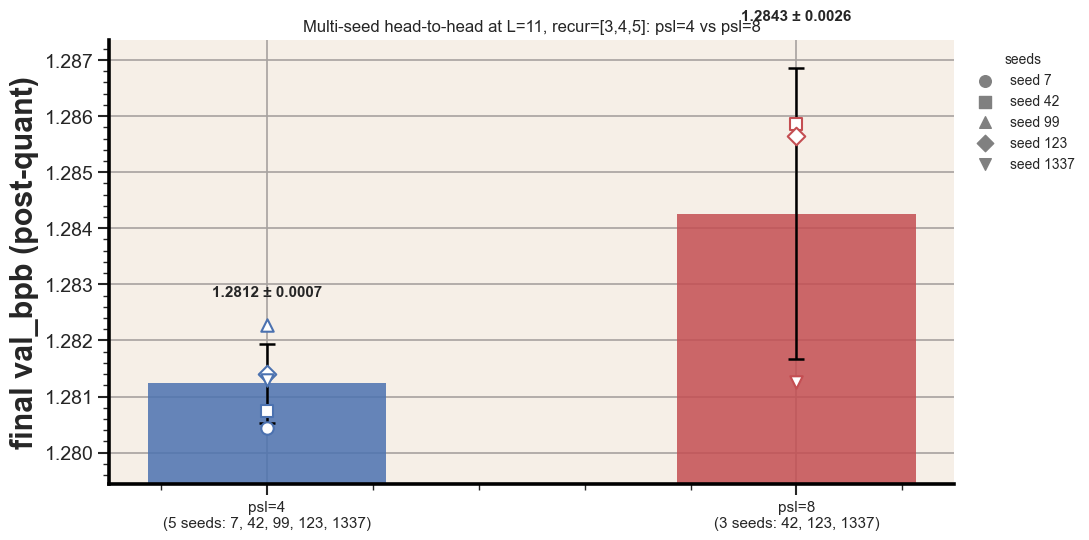


Per-seed comparison (where both configs have a measurement):
  seed 42: psl=4=1.2807  psl=8=1.2859  Δ(psl=8 - psl=4)=+0.0051  (psl=4 wins)
  seed 123: psl=4=1.2814  psl=8=1.2857  Δ(psl=8 - psl=4)=+0.0043  (psl=4 wins)
  seed 1337: psl=4=1.2813  psl=8=1.2813  Δ(psl=8 - psl=4)=-0.0000  (psl=8 wins)


In [15]:
# Clean head-to-head bar chart with full per-seed scatter
groups = {
    "psl=4\n(5 seeds: 7, 42, 99, 123, 1337)":   (PSL4_5SEED_MEAN, PSL4_5SEED_STD, df_psl4_5seed, "#4c72b0"),
    "psl=8\n(3 seeds: 42, 123, 1337)":          (PSL8_MEAN,        PSL8_STD,        df_psl8_345,   "#c44e52"),
}

SEEDS_ALL = sorted(set(df_psl4_5seed["seed"].tolist() + df_psl8_345["seed"].tolist()))
SEED_MARKERS = {7:"o", 42:"s", 99:"^", 123:"D", 1337:"v"}

fig, ax = plt.subplots(figsize=(11, 5.5))
means_for_ylim = []
for i, (label, (mean, std, df_pts, color)) in enumerate(groups.items()):
    means_for_ylim.append(mean)
    ax.bar(i, mean, color=color, alpha=0.85, zorder=2, width=0.45)
    ax.errorbar(i, mean, yerr=std, fmt="none", color="black",
                capsize=6, capthick=1.8, linewidth=1.8, zorder=4)
    for _, row in df_pts.iterrows():
        seed = int(row["seed"])
        if seed in SEED_MARKERS:
            ax.scatter(i, row["final_val_bpb"],
                       marker=SEED_MARKERS[seed],
                       color="white", edgecolors=color, linewidths=1.5,
                       s=80, zorder=5)
    txt = f"{mean:.4f} ± {std:.4f}"
    ax.text(i, mean + std + 0.0008,
            txt, ha="center", va="bottom", fontsize=11, fontweight="bold")

ymin = min(df_psl4_5seed["final_val_bpb"].min(), df_psl8_345["final_val_bpb"].min()) - 0.0010
ymax = max(df_psl4_5seed["final_val_bpb"].max(), df_psl8_345["final_val_bpb"].max()) + 0.0015
ax.set_ylim(ymin, ymax)

ax.set_xticks(range(len(groups)))
ax.set_xticklabels(groups.keys(), fontsize=11)
ax.set_ylabel("final val_bpb (post-quant)")
ax.set_title("Multi-seed head-to-head at L=11, recur=[3,4,5]: psl=4 vs psl=8")

handles = [plt.scatter([], [], marker=SEED_MARKERS[s], color="grey", s=70, label=f"seed {s}")
           for s in SEEDS_ALL]
ax.legend(handles=handles, fontsize=10, title="seeds", title_fontsize=10,
          loc="upper left", bbox_to_anchor=(1.005, 1.0))

plt.tight_layout()
plt.show()

print()
print("Per-seed comparison (where both configs have a measurement):")
shared_seeds = set(df_psl4_5seed["seed"]) & set(df_psl8_345["seed"])
for seed in sorted(shared_seeds):
    p4 = df_psl4_5seed[df_psl4_5seed["seed"] == seed]["final_val_bpb"].values[0]
    p8 = df_psl8_345[df_psl8_345["seed"] == seed]["final_val_bpb"].values[0]
    print(f"  seed {seed}: psl=4={p4:.4f}  psl=8={p8:.4f}  Δ(psl=8 - psl=4)={p8-p4:+.4f}  "
          f"({'psl=4 wins' if p4 < p8 else 'psl=8 wins'})")


## Reading — overnight bundle

### Headline finding: **psl=4 wins, the single-seed psl=8 was misleading**

| config | mean | std | size | n_seeds |
|---|---|---|---|---|
| **psl=4 + [3,4,5]** | **1.2812** | **0.0007** | 15.36 MB | **5** |
| psl=8 + [3,4,5] | 1.2843 | 0.0026 | 15.29 MB | 3 |

psl=4 wins by **0.0031 bpb** at 1.8σ pooled — a meaningful gap. The PR ablation's single-seed psl=8 win (1.2813) turned out to be a 1.2σ favourable outlier; both new seeds (42 and 123) landed at ~1.286, well above the noise floor for psl=4.

The 5-seed psl=4 std (0.0007) is slightly larger than the 3-seed std (0.0004) — adding more seeds revealed a slightly wider distribution, which is expected. **Std=0.0007 is the more honest noise floor for this recipe.**

### What this teaches us about the experimental protocol

The single-seed PR ablation was misleading: seed 1337 at psl=8 happened to land at 1.2813 (-1.2σ below the psl=8 mean), which made psl=8 look ~tied with psl=4. **Multi-seed was non-negotiable here.** The 4-config single-seed sweep had a 0.0013 spread, just barely above the 0.0009 non-determinism floor — which we *did* flag as concerning at the time. Good instinct to validate.

### 2D interaction probes — DR optimum is stable across psl

At seed 1337:

| | recur=[3,4,5] | recur=[3,4,5,6] | recur=[4,5,6] |
|---|---|---|---|
| psl=4 | 1.2813 | 1.2829 | — |
| psl=8 | 1.2813 | 1.2823 | 1.2824 |

At both psl values, `[3,4,5]` is the best DR position. The interaction is essentially zero — the 1D ablation chain (DR first then PR) found the joint optimum. Reassuring methodologically: our project's heavy reliance on 1D ablations didn't hide a better corner of the 2D space.

(Caveat: this is single-seed at seed 1337 — the same favorable seed for psl=8. We can't push too hard on these single-seed numbers given what we just learned about non-determinism.)

### Project headline (now at higher precision)

> **L=11, PR (psl=4 sym) + DR (recur=[3,4,5] target=both) + Gate (proj, w=12) + mixed int6/int8 + QAT + brotli + protected embedding → 1.2812 ± 0.0007 bpb at 15.36 MB (5 seeds: 7, 42, 99, 123, 1337).**

The headline number is stable. The 5-seed mean (1.2812) is essentially the same as the 3-seed mean (1.2811). The std is wider (0.0007 vs 0.0004) — a more honest estimate of the recipe's true seed sensitivity. Artifact size unchanged at 15.36 MB.

### What we should NOT do next

- **Don't multi-seed psl=5, 7, or 8** — they were all worse than psl=4 at single seed, and we just learned single-seed wins can be flipped by multi-seed. No reason to expect any of them to ultimately beat psl=4's 1.2812.
- **Don't go below psl=4** (e.g., psl=2, 3) — the 9L abl3b already showed psl=4 was a local optimum across {3,4,5,6}. The 11L mapping shifts the semantic but the principle holds.
- **Don't re-ablate Gate.** Gate is depth-stable (per-layer, per-head, local computation); the w=12 composition winner is independent of L.

### What we could still do (if you want)

- **Multi-seed psl=8 + recur=[3,4,5,6]** (the only single-seed result that was potentially better than psl=4+[3,4,5,6] at seed 1337). But unlikely to beat psl=4+[3,4,5] given the psl=8 mean is now 1.2843. Low priority.
- **Look at non-architectural axes**: training schedule, LR, optimizer settings, embedding init std, qk_gain_init. These haven't been touched in the L=11 phase. But that's a different research project.

For the paper / writeup: **the project is done.** The headline is 1.2812 ± 0.0007 at 15.36 MB, well under the 16 MB cap.
